In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
db = pd.read_csv("Australian Vehicle Prices.csv")

In [4]:
db.info()
db.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16734 entries, 0 to 16733
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              16733 non-null  object 
 1   Year               16733 non-null  float64
 2   Model              16733 non-null  object 
 3   Car/Suv            16706 non-null  object 
 4   Title              16733 non-null  object 
 5   UsedOrNew          16733 non-null  object 
 6   Transmission       16733 non-null  object 
 7   Engine             16733 non-null  object 
 8   DriveType          16733 non-null  object 
 9   FuelType           16733 non-null  object 
 10  FuelConsumption    16733 non-null  object 
 11  Kilometres         16733 non-null  object 
 12  ColourExtInt       16733 non-null  object 
 13  Location           16284 non-null  object 
 14  CylindersinEngine  16733 non-null  object 
 15  BodyType           16452 non-null  object 
 16  Doors              151

Brand                   1
Year                    1
Model                   1
Car/Suv                28
Title                   1
UsedOrNew               1
Transmission            1
Engine                  1
DriveType               1
FuelType                1
FuelConsumption         1
Kilometres              1
ColourExtInt            1
Location              450
CylindersinEngine       1
BodyType              282
Doors                1604
Seats                1705
Price                   3
dtype: int64

Eliminar autos sin precio: Como definimos en nuestra pregunta de negocio, el objetivo es predecir el precio. Un registro sin precio no nos sirve para aprender, así que eliminaremos esas filas.

Forzar la conversión a número: Usaremos una función muy útil de pandas llamada pd.to_numeric(). Esta función intentará convertir todo a números. Si encuentra un texto raro (como un guion -), lo convertiremos en un valor nulo (NaN) a propósito usando el parámetro errors='coerce'.

Rellenar los kilómetros faltantes: En lugar de borrar los autos a los que les faltan los kilómetros (perderíamos muchos datos), rellenaremos esos vacíos con la mediana (el valor central) de todos los kilómetros del dataset. Es una técnica clásica para no perder información valiosa.

In [5]:
 db_copia = db.copy()

print(f"Registros totales: {len(db_copia)}")
print(f"Registros sin precio (NaN): {db_copia['Price'].isna().sum()}")

# Eliminar filas donde el precio es nulo
db_copia = db_copia.dropna(subset=['Price'])

# Verificar después de eliminar
print(f"Registros después de eliminar sin precio: {len(db_copia)}")
print(db_copia["Price"])

Registros totales: 16734
Registros sin precio (NaN): 3
Registros después de eliminar sin precio: 16731
0         51990
1         19990
2        108988
3         32990
4         34990
          ...  
16729     29500
16730     39888
16731     35280
16732     41888
16733     65888
Name: Price, Length: 16731, dtype: object


In [6]:
from numpy import median

db_copia['Price'] = pd.to_numeric(db_copia["Price"],errors='coerce')
db_copia["Kilometres"] = pd.to_numeric(db_copia["Kilometres"],errors='coerce')
mediana_km = db_copia["Kilometres"].median()
db_copia["Kilometres"] = db_copia["Kilometres"].fillna(mediana_km)
db_copia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16731 entries, 0 to 16733
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              16731 non-null  object 
 1   Year               16731 non-null  float64
 2   Model              16731 non-null  object 
 3   Car/Suv            16704 non-null  object 
 4   Title              16731 non-null  object 
 5   UsedOrNew          16731 non-null  object 
 6   Transmission       16731 non-null  object 
 7   Engine             16731 non-null  object 
 8   DriveType          16731 non-null  object 
 9   FuelType           16731 non-null  object 
 10  FuelConsumption    16731 non-null  object 
 11  Kilometres         16731 non-null  float64
 12  ColourExtInt       16731 non-null  object 
 13  Location           16282 non-null  object 
 14  CylindersinEngine  16731 non-null  object 
 15  BodyType           16450 non-null  object 
 16  Doors              15129 no

In [7]:
# 1. Eliminamos definitivamente cualquier fila donde 'Price' sea un valor nulo (NaN) ( Tenemos menos datos en price )
db_copia = db_copia.dropna(subset=['Price'])

# 2. Mostramos la información para confirmar que ambas tengan el mismo número
print("--- Verificación final de limpieza ---")
print(db_copia[['Price', 'Kilometres']].info())


--- Verificación final de limpieza ---
<class 'pandas.core.frame.DataFrame'>
Index: 16681 entries, 0 to 16733
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Price       16681 non-null  float64
 1   Kilometres  16681 non-null  float64
dtypes: float64(2)
memory usage: 391.0 KB
None


# Funcion para elimnar datos de una columna 

Tu código actual (.str.extract) → Perfecto para extraer el PRIMER número

replace → Bueno cuando quieres limpiar y dejar solo números

split → Ideal si el formato es siempre igual

In [8]:
# El patrón r'(\d+\.?\d*)' significa:
# \d+   -> Busca uno o más números (ej. el 8)
# \.?   -> Puede que haya un punto decimal o no
# \d* -> Puede que haya más números después del punto (ej. el 7)
db_copia["FuelConsumption_per_km"]= db_copia['FuelConsumption'].str.extract(r'(\d+\.?\d*)')
db_copia.head()
db_copia["FuelConsumption_per_km"] = pd.to_numeric(db_copia["FuelConsumption_per_km"],errors='coerce')
# db_copia = db_copia.drop("FuelConsmption_per_km",axis=1)
# Nos fijamos que hay valores null entonces debemos rellenar
mediana_fuel_per_km = db_copia['FuelConsumption_per_km'].median()
print(f"mediana per km: {mediana_fuel_per_km}")
db_copia["FuelConsumption_per_km"]
db_copia["FuelConsumption_per_km"] = db_copia["FuelConsumption_per_km"].fillna(mediana_fuel_per_km)
db_copia.info()

mediana per km: 7.6
<class 'pandas.core.frame.DataFrame'>
Index: 16681 entries, 0 to 16733
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Brand                   16681 non-null  object 
 1   Year                    16681 non-null  float64
 2   Model                   16681 non-null  object 
 3   Car/Suv                 16655 non-null  object 
 4   Title                   16681 non-null  object 
 5   UsedOrNew               16681 non-null  object 
 6   Transmission            16681 non-null  object 
 7   Engine                  16681 non-null  object 
 8   DriveType               16681 non-null  object 
 9   FuelType                16681 non-null  object 
 10  FuelConsumption         16681 non-null  object 
 11  Kilometres              16681 non-null  float64
 12  ColourExtInt            16681 non-null  object 
 13  Location                16232 non-null  object 
 14  CylindersinEngine      

Necesitamos extraer de Engine solo la cantidad de cilindros y los litros del motor

In [9]:



db_copia["CylindersinEngine"] = db_copia["Engine"].astype(str).str.extract(r'(\d+)',expand=False)
db_copia["CylindersinEngine"] = pd.to_numeric(db_copia["CylindersinEngine"],errors='coerce')
mediana_cyl = db_copia["CylindersinEngine"].median()
db_copia["CylindersinEngine"] = db_copia["CylindersinEngine"].fillna(mediana_cyl)


# El patrón r'(\d+\.?\d*)\s*L' busca el número decimal que está justo antes de la letra 'L'
db_copia["LiterEngine"] = db_copia["Engine"].astype(str).str.extract(r'(\d+\.?\d*)\s*L', expand=False)
db_copia["LiterEngine"] = pd.to_numeric(db_copia["LiterEngine"],errors='coerce')
mediana_lt = db_copia["LiterEngine"].median()
db_copia["LiterEngine"] = db_copia["LiterEngine"].fillna(mediana_lt)
db_copia.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16681 entries, 0 to 16733
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Brand                   16681 non-null  object 
 1   Year                    16681 non-null  float64
 2   Model                   16681 non-null  object 
 3   Car/Suv                 16655 non-null  object 
 4   Title                   16681 non-null  object 
 5   UsedOrNew               16681 non-null  object 
 6   Transmission            16681 non-null  object 
 7   Engine                  16681 non-null  object 
 8   DriveType               16681 non-null  object 
 9   FuelType                16681 non-null  object 
 10  FuelConsumption         16681 non-null  object 
 11  Kilometres              16681 non-null  float64
 12  ColourExtInt            16681 non-null  object 
 13  Location                16232 non-null  object 
 14  CylindersinEngine       16681 non-null  flo

# Preparamos la tabla final que usaremos para el algortimo

In [10]:
columnas_numericas = ['Price', 'Year', 'Kilometres', 'FuelConsumption_per_km', 'CylindersinEngine', 'LiterEngine']
columnas_texto = ['UsedOrNew', 'Transmission', 'FuelType']

# Creamos un nuevo DataFrame solo con estas características
df_limpio = db_copia[columnas_numericas + columnas_texto].copy()

# La función pd.get_dummies crea estas nuevas columnas mágicamente.
# drop_first=True evita redundancias (ej. si no es Automático, asume que es Manual, ahorrando una columna)
df_ml = pd.get_dummies(df_limpio,columns=columnas_texto,drop_first= True)
df_ml["Year"] = df_ml["Year"].astype(int)
df_ml.head()

,Price,Year,Kilometres,FuelConsumption_per_km,CylindersinEngine,LiterEngine,UsedOrNew_NEW,UsedOrNew_USED,Transmission_Automatic,Transmission_Manual,FuelType_Diesel,FuelType_Electric,FuelType_Hybrid,FuelType_LPG,FuelType_Leaded,FuelType_Other,FuelType_Premium,FuelType_Unleaded
0,51990.0,2022,5595.0,8.7,4.0,2.2,False,False,True,False,True,False,False,False,False,False,False,False
1,19990.0,2022,16.0,6.7,4.0,1.5,False,True,True,False,False,False,False,False,False,False,True,False
2,108988.0,2022,8472.0,6.6,4.0,2.0,False,True,True,False,False,False,False,False,False,False,True,False
3,32990.0,2011,136517.0,11.0,8.0,5.5,False,True,True,False,False,False,False,False,False,False,True,False
4,34990.0,2022,1035.0,6.0,4.0,1.3,False,True,True,False,False,False,False,False,False,False,False,True


# Comenzamos con el entrenamiento


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Designamos nuestra X e y luego dividimos en entrenamiento y prueba con la funcion train_test_split
X = df_ml.drop("Price",axis=1)
y = df_ml['Price']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [12]:
# Creamos nuestro modelo y entrenamos
# n_estimators=100 significa que creará 100 "árboles" para tomar la decisión
modelo_rf = RandomForestRegressor(n_estimators=100,random_state=42)

modelo_rf.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
predicciones = modelo_rf.predict(X_test)
mae = mean_absolute_error(y_test,predicciones)
print(f"En promedio, nuestro modelo se equivoca por: ${mae:,.2f} dólares australianos.")

En promedio, nuestro modelo se equivoca por: $7,723.68 dólares australianos.


In [29]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# 2. Calculamos el R2 Score
r2_rf = r2_score(y_test, predicciones)
# 3. Calculamos el RMSE (Raíz del Error Cuadrático Medio)
rmse_rf = np.sqrt(mean_squared_error(y_test, predicciones))

print(f"El r2 del modelo es: {r2_rf}")
print(f"El RMSE del modelo es: {rmse_rf}")

El r2 del modelo es: 0.7557765860258422
El RMSE del modelo es: 18562.923964346028


# Visualizamos los resultados


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
Importancias = modelo_rf.feature_importances_
df_importancias = pd.DataFrame({'Caracteristicas':X.columns,'Importancias':Importancias})
df_importancias = df_importancias.sort_values(by='Importancias',ascending=False).head(10)
df_importancias.head()


,Caracteristicas,Importancias
0,Year,0.309395
3,CylindersinEngine,0.223475
1,Kilometres,0.181393
4,LiterEngine,0.110070
2,FuelConsumption_per_km,0.085011


C:\Users\mmora\AppData\Local\Temp\ipykernel_21492\3142011259.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancias', y='Caracteristicas', data=df_importancias, palette='viridis')


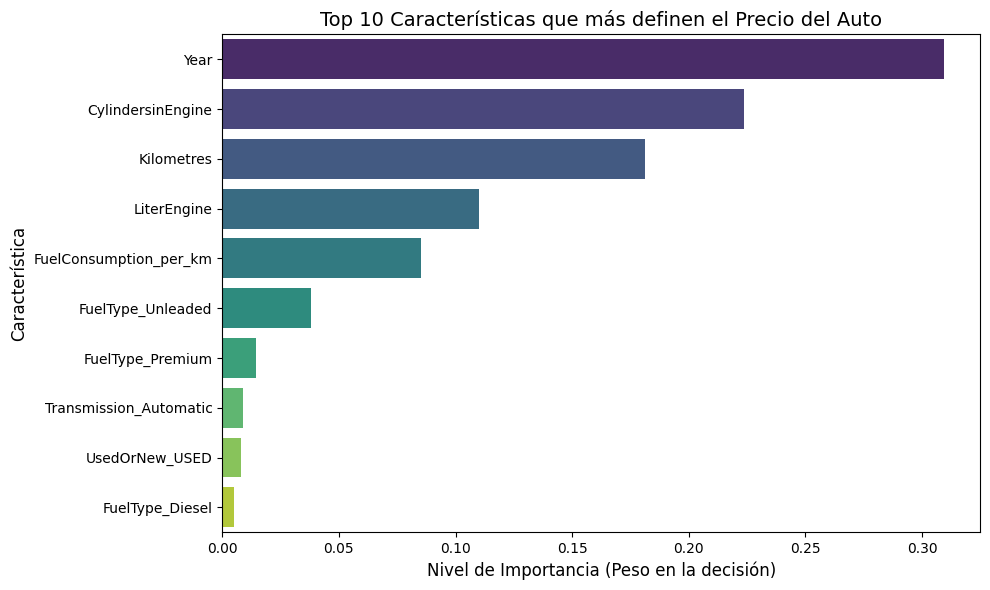

In [16]:
plt.figure(figsize=(10, 6)) # Tamaño del gráfico
sns.barplot(x='Importancias', y='Caracteristicas', data=df_importancias, palette='viridis')

# Añadimos títulos y etiquetas para que sea fácil de entender
plt.title('Top 10 Características que más definen el Precio del Auto', fontsize=14)
plt.xlabel('Nivel de Importancia (Peso en la decisión)', fontsize=12)
plt.ylabel('Característica', fontsize=12)

# Mostramos el gráfico
plt.tight_layout()
plt.show()

# Modelo Extra-Trees


In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error

# Creamos el modelo pero esta vez con límites estrictos de memoria
modelo_et = ExtraTreesRegressor(
    n_estimators=100, 
    max_depth=15,       # ¡El secreto! Evita que los árboles colapsen la RAM
    random_state=42,
    n_jobs=1            # Trabajo seguro de un solo núcleo
)

modelo_et.fit(X_train, y_train)

# Le tomamos el examen final
predicciones_et = modelo_et.predict(X_test)
mae_et = mean_absolute_error(y_test, predicciones_et)

print(f"Error promedio de Extra-Trees: ${mae_et:,.2f} dólares australianos.")

Entrenando el modelo Extra-Trees (Modo Seguro)...

--- ¡Entrenamiento Finalizado! ---
Error promedio de Extra-Trees: $8,093.74 dólares australianos.


In [21]:
r2_et = r2_score(y_test,predicciones_et)
rmse_et = np.sqrt(mean_squared_error(y_test,predicciones_et))

print(f"El r2 del modelo et es: {r2_et}")
print(f"El rmse del modelo et es: {rmse_et}")

El r2 del modelo et es: 0.7161421720697685
El rmse del modelo et es: 20012.58430438523


## Evaluación de Modelos y Métricas Matemáticas

Para medir el éxito de nuestros algoritmos de predicción de precios, utilizamos tres de las métricas más importantes en problemas de regresión. Comparar estas métricas nos permite entender el margen de error y cómo se comporta el modelo ante casos extremos (outliers).

* **MAE (Mean Absolute Error - Error Absoluto Medio):** Nos indica, en promedio, por cuántos dólares se equivoca nuestro modelo en cada predicción. Mide la diferencia absoluta entre el precio real ($y_i$) y el precio predicho ($\hat{y}_i$).
$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
*En este caso, el Random Forest tiene un error promedio de ~$7,723 AUD por vehículo.*

* **RMSE (Root Mean Squared Error - Raíz del Error Cuadrático Medio):** A diferencia del MAE, el RMSE penaliza fuertemente los errores muy grandes, ya que eleva las diferencias al cuadrado antes de promediarlas y sacar la raíz. 
$$RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$
*Nuestro RMSE (~18,562 AUD) es mayor que el MAE, lo que indica que el modelo generalmente acierta de cerca, pero ocasionalmente comete errores grandes (por ejemplo, con vehículos exóticos o de colección).*

* **R² (R-Squared - Coeficiente de Determinación):** Es una métrica que evalúa qué tan bien las variables independientes (Año, Kilómetros, Motor, etc.) explican la varianza de la variable dependiente (Precio). Compara los errores de nuestro modelo con los errores de un modelo muy simple que solo predijera el promedio ($\bar{y}$).
$$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$
*Nuestro Random Forest alcanzó un **R² de 0.755**, lo que significa que es capaz de explicar el **75.5%** de la variación en los precios de los automóviles.*